# Notebook for overall pipeline debugging

In [22]:
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

## MNIST

In [43]:
import torch
from tensorflow.keras.datasets import mnist
(x_train, y_train_ds), (x_test, y_test_ds) = mnist.load_data()

def load_mnist(X,y,n,test_size=0.2):
    X_mnist = X[:n] / 255.0
    y_mnist = y[:n]

    X_mnist = X_mnist.reshape(-1, 1, 28, 28)

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X_mnist, y_mnist, test_size=test_size, stratify=y_mnist, random_state=0
    # )

    X_train = torch.tensor(X_mnist, dtype=torch.float32)
    # X_test = torch.tensor(X_test, dtype=torch.float32)

    return X_train, y

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [47]:
def plot_reconstructions_convvae(model, X, n=10):
    device = next(model.parameters()).device
    idx = np.random.choice(len(X), n, replace=False)
    originals = X[idx].detach().cpu().numpy() # Keep the (batch_size, 1, 8, 8) shape

    if isinstance(model, VAE):
        x_hat, _, _, _ = model(X[idx].to(device))
    else:
        x_hat = model(X[idx].to(device))

    recons = x_hat.cpu().detach().numpy() # Keep the (batch_size, 1, 8, 8) shape

    plt.figure(figsize=(10, 3))
    for i in range(n):
        # original: reshape from (1, 8, 8) to (8, 8)
        plt.subplot(2, n, i+1)
        plt.imshow(originals[i].reshape(28,28), cmap='gray')
        plt.axis('off')

        # reconstruction: reshape from (1, 8, 8) to (8, 8)
        plt.subplot(2, n, n + i + 1)
        plt.imshow(recons[i].reshape(28,28), cmap='gray')
        plt.axis('off')

    plt.suptitle("Original (top) vs Reconstruction (bottom)")
    plt.show()

Check VAE model loads correctly

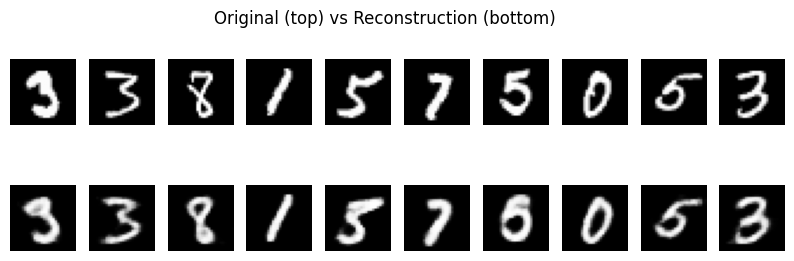

In [49]:
import numpy as np
from src.architecture.vae import VAE
import yaml

device = 'cpu'

with open("_config/vae_training.yaml", 'r') as f:
    model_cfg = yaml.safe_load(f)

model = VAE(**model_cfg['model_params']).to(device)
model.load_state_dict(torch.load(model_cfg["pth_path"], map_location=torch.device('cpu')))
model.eval()

X_test = torch.tensor(x_test/255.0, dtype=torch.float32).reshape(-1, 1, 28, 28)

plot_reconstructions_convvae(model, X_test, n=10)

## Run experiment for VAE

In [18]:
import os 
%cd .UNIVERSIDAD/HEIDELBERG/GNNS/GenNN-InverseMicro/
os.getcwd()

[WinError 3] El sistema no puede encontrar la ruta especificada: '.UNIVERSIDAD/HEIDELBERG/GNNS/GenNN-InverseMicro/'
c:\Users\jutri\Documents\.UNIVERSIDAD\HEIDELBERG\GNNS\GenNN-InverseMicro


'c:\\Users\\jutri\\Documents\\.UNIVERSIDAD\\HEIDELBERG\\GNNS\\GenNN-InverseMicro'

In [77]:
from main import run_experiment
from src.operators import Operator

H = Operator(channels=1, scale_factor=4)

y_real = X_test[3]
img_noisy = H.forward(y_real.unsqueeze(0))
img_recon = run_experiment(img_noisy, method='vae')

100%|██████████| 5000/5000 [00:08<00:00, 561.99it/s]


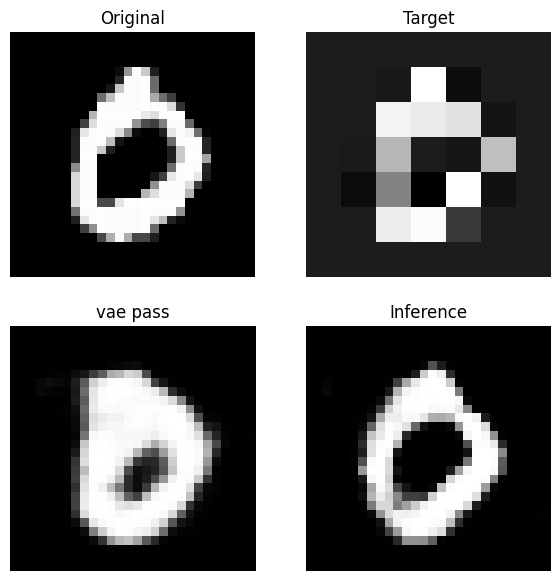

In [78]:
plt.figure(figsize=(7,7))

y_target = img_noisy
y_sol = img_recon

# original: reshape from (1, 8, 8) to (8, 8)
ax = plt.subplot(2, 2, 1)
ax.imshow(y_real.cpu().reshape(28,28), cmap='gray')
ax.set_title("Original")
ax.axis('off')

ax = plt.subplot(2, 2, 2)
ax.imshow(y_target.cpu().detach().numpy().reshape(28,28), cmap='gray')
ax.set_title("Target")
ax.axis('off')

# reconstruction: reshape from (1, 8, 8) to (8, 8)
ax = plt.subplot(2, 2, 4)
ax.imshow(y_sol.cpu().reshape(28,28), cmap='gray')
ax.set_title("Inference")
ax.axis('off')

ax =plt.subplot(2, 2, 3)
x_pass, _, _, _ = model(y_target.to(device))
ax.imshow(x_pass.cpu().detach().numpy().reshape(28,28), cmap='gray')
ax.set_title("vae pass")
ax.axis('off')

plt.show()

The pipeline configured for the vae model and latent inference correctly works. The next steps would be training on the final dataset and hyperparameter tuning for the inference solver on the latent space.

## CIFAR10

100%|██████████| 170M/170M [03:04<00:00, 924kB/s]  


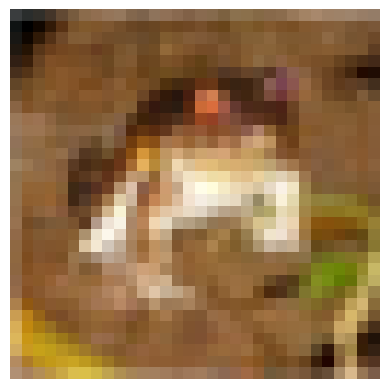

In [76]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),               # [0, 1]
    transforms.Normalize((0.5,), (0.5,)) # [-1, 1]
])

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

img_cifar, label = dataset[0]
y_true = img_cifar.unsqueeze(0)

def show_tensor(tensor):
    img = (tensor.clamp(-1, 1) + 1) / 2
    img = img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_tensor(y_true)

## Run experiment for diffusion

Now we use the CIFAR10 dataset

In [79]:
img_cifar, label = dataset[0]
y_true = img_cifar

img_noisy = H.forward(y_true.unsqueeze(0))
img_recon = run_experiment(img_noisy, method='red-diff')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
C:\Users\jutri\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


AssertionError: Torch not compiled with CUDA enabled